# Helmholtz scattering

!!! note "Important points covered in this example"
      - Creating a geometry using the *Gmsh* API
      - Assembling integral operators and integral potentials
      - Setting up a sound-soft problem in both 2 and 3 spatial dimensions
      - Compressing integral operators using [`HMatrices.jl`](https://github.com/WaveProp/HMatrices.jl)
      - Solving a boundary integral equation
      - Exporting the solution to *Gmsh* for visualization

In this tutorial we will show how to solve an acoustic scattering problem in
the context of Helmholtz equation. We will focus on a *smooth* sound-soft
obstacle for simplicity, and introduce along the way the necessary techniques
used to handle some difficulties encountered. We will use various packages
throughout this example (including of course `Inti.jl`); if they are not on
your environment, you can install them using `] add <package>` in the REPL.

In the following section, we will provide a brief
mathematical description of the problem (valid in both $2$ and $3$
dimensions). We will tackle the [two-dimensional problem](@ref
helmholtz-scattering-2d) first, for which we do not need to worry much about
performance issues (e.g. compressing the integral operators, or exporting the
solution to *Gmsh* for visualization). Finally, we present a [three-dimensional
example](@ref helmholtz-scattering-3d), where we will use
[`HMatrices.jl`](https://github.com/WaveProp/HMatrices.jl) to compress the
underlying integral operators.

## Sound-soft problem

This example concerns the sound-soft acoustic scattering problem.
Mathematically, this means solving an exterior problem governed by Helmholtz
equation (time-harmonic acoustics) with a Dirichlet boundary condition. More
precisely, letting $\Omega \subset \mathbb{R}^d$ be a bounded domain, and denoting
by $\Gamma = \partial \Omega$ its boundary, we wish to solve

$$
    \Delta u + k^2 u = 0 \quad \text{on} \quad \mathbb{R}^d \setminus \bar{\Omega},
$$

subject to Dirichlet boundary conditions on $\Gamma$

$$
    u(\boldsymbol{x}) = g(\boldsymbol{x}) \quad \text{for} \quad \boldsymbol{x} \in \Gamma.
$$

and the *Sommerfeld radiation condition* at infinity

$$
    \lim_{|\boldsymbol{x}| \to \infty} \|\boldsymbol{x}|^{(d-1)/2} \left( \frac{\partial u}{\partial |\boldsymbol{x}|} - i k u \right) = 0.
$$

Here $g$ is a (given) boundary datum, and $k$ is the constant wavenumber.

For simplicity, we will take $\Gamma$ circle/sphere, and focus on the
*plane-wave scattering* problem. This means we will seek a solution $u$ of
the form $u = u_s + u_i$, where $u_i$ is a known incident field, and
$u_s$ is the scattered field we wish to compute.

!!! note "Complex geometries"
      The main reason for focusing on such a simple example is two-folded. First,
      it alleviates the complexities associated with the mesh generation. Second,
      since exact solutions are known for this problem (in the form of a series),
      it is easy to assess the accuracy of the solution obtained. In practice, you
      can use the same techniques to solve the problem on more complex geometries
      by providing a `.msh` file containing the mesh.

Using the theory of
boundary integral equations, we can express $u_s$ as

$$
    u_s(\boldsymbol{r}) = \mathcal{D}[\sigma](\boldsymbol{r}) - i k \mathcal{S}[\sigma](\boldsymbol{r}),
$$

where $\mathcal{S}$ is the so-called single layer potential, $\mathcal{D}$
is the double-layer potential, and $\sigma : \Gamma \to \mathbb{C}$ is a
surface density. This is an indirect formulation (because $\sigma$ is an
*auxiliary* density, not necessarily physical) commonly referred to as a
*combined field formulation*. Taking the limit $\mathbb{R}^d \setminus \bar
\Omega \ni x \to \Gamma$, it can be shown that the following equation holds
on $\Gamma$:

$$
    \left( \frac{\mathrm{I}}{2} + \mathrm{D} - i k \mathrm{S} \right)[\sigma] = g,
$$

where $\mathrm{I}$ is the identity operator, and $\mathrm{S}$ and $\mathrm{D}$
are the single- and double-layer operators. This is the **combined field
integral equation** that we will solve. The boundary data $g$ is obtained by
applying the sound-soft condition $u=0$ on $\Gamma$, from which it readily
follows that $u_s = -u_i$ on $\Gamma$.

We are now have the necessary background to solve this problem in both 2 and 3
spatial dimensions. Let's load `Inti.jl`

In [1]:
using Inti

## Two-dimensional scattering

We use [Gmsh
API](https://gmsh.info/doc/texinfo/gmsh.html#Gmsh-application-programming-interface)
for creating `.msh` file containing the desired geometry and mesh, and then
import it into `Inti` using `gmsh_read_msh`. Here
is a function to mesh the circle:

In [2]:
using Gmsh # this will trigger the loading of Inti's Gmsh extension

function gmsh_circle(;name, meshsize, order=1, radius=1, center = (0,0))
    try
        gmsh.initialize()
        gmsh.model.add("circle-mesh")
        gmsh.option.setNumber("Mesh.MeshSizeMax", meshsize)
        gmsh.option.setNumber("Mesh.MeshSizeMin", meshsize)
        gmsh.model.occ.addDisk(center[1], center[2], 0, radius, radius)
        gmsh.model.occ.synchronize()
        gmsh.model.mesh.generate(1)
        gmsh.model.mesh.setOrder(order)
        gmsh.write(name)
    finally
        gmsh.finalize()
    end
end

gmsh_circle (generic function with 1 method)

Let us now use to create a `circle.msh` file:

In [3]:
name = joinpath(@__DIR__, "circle.msh")
gmsh_circle(;meshsize=0.1, order = 2, name)

Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 0.000203856s, CPU 0.000174s)
Info    : 63 nodes 64 elements
Info    : Meshing order 2 (curvilinear on)...
Info    : [  0%] Meshing curve 1 order 2
Info    : [ 50%] Meshing surface 1 order 2
Info    : Done meshing order 2 (Wall 0.000592828s, CPU 0.000479s)
Info    : Writing '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/circle.msh'...
Info    : Done writing '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/circle.msh'


We can now import the file and parse the mesh and domain information into
`Inti.jl` using the `gmsh_read_msh` function:

In [4]:
Ω,msh = Inti.gmsh_read_msh(name; dim=2)
@show Ω

Info    : Reading '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/circle.msh'...
Info    : 3 entities
Info    : 126 nodes
Info    : 64 elements
Info    : Done reading '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/circle.msh'
Ω = Domain with 1 entity:
	 IntiGmshExt.GmshEntity with (dim,tag)=(2,1)


Domain with 1 entity:
	 IntiGmshExt.GmshEntity with (dim,tag)=(2,1)

In [5]:
@show msh

msh = Inti.LagrangeMesh{2, Float64} containing:
	 63 elements of type Inti.LagrangeElement{Inti.ReferenceHyperCube{1}, 3, StaticArraysCore.SVector{2, Float64}}


Inti.LagrangeMesh{2, Float64} containing:
	 63 elements of type Inti.LagrangeElement{Inti.ReferenceHyperCube{1}, 3, StaticArraysCore.SVector{2, Float64}}

The code above will parse all entities in the `name` of dimension `2` as a
`Domain`, and also import the underlying mesh (that, in
this case, is projected into two dimensions by ignoring the third component).
Note that in the example above, `Ω` is a two-dimensional domain containing a
single `GmshEntity` which represents the disk. To extract the boundary $\Gamma
= \partial \Omega$, we can use the `boundary` function:

In [6]:
Γ = Inti.boundary(Ω)

Domain with 1 entity:
	 IntiGmshExt.GmshEntity with (dim,tag)=(1,1)

!!! tip "Views of a mesh"
      In `Inti.jl`, you can use domain to create a view of a mesh containing *only
      the elements in the domain*. For example `view(msh,Γ)` will return an
      abstract mesh that you can use to iterate over the elements in the boundary
      of the disk.

To solve our boundary integral equation usign a Nyström method, we actually
need a quadrature of our curve/surface (and possibly the normal vectors at the
quadrature nodes). Once a mesh is available, creating a quadrature object can
be done via the `Quadrature` constructor, which
requires passing a mesh the domain that one wishes to generate a quadrature
for:

In [7]:
Γ = Inti.boundary(Ω)
Q = Inti.Quadrature(msh, Γ; qorder = 4)
nothing #hide

The object `Q` now contains a quadrature (of order `4`) that can be used to
solve a boundary integral equation on `Γ`. As a sanity check, let's make sure
integrating the function `x->1` over `Q` gives an approximation to the perimeter:

In [8]:
@assert abs(Inti.integrate(x->1,Q) - 2π) < 1e-5 #hide
Inti.integrate(x->1,Q) - 2π

-6.470135645031405e-7

With the `Quadrature` constructed, we now can define
discrete approximation to the integral operators $\mathrm{S}$ and
$\mathrm{D}$ as follows:

In [9]:
k = 4π
pde   = Inti.Helmholtz(;k, dim=2)
G     = Inti.SingleLayerKernel(pde)
dGdny = Inti.DoubleLayerKernel(pde)
Sop = Inti.IntegralOperator(G,Q,Q)
Dop = Inti.IntegralOperator(dGdny,Q,Q)

315×315 Inti.IntegralOperator{ComplexF64}:
         -0.0-0.0im          …  -0.000677086-1.99024e-6im
 -0.000700769-2.69058e-5im      -0.000718996-4.33871e-5im
 -0.000789816-0.000177498im     -0.000802427-0.000214251im
 -0.000819864-0.000431649im     -0.000815473-0.000481194im
 -0.000782099-0.000618282im     -0.000763904-0.000670663im
 -0.000763175-0.000670023im  …  -0.000741036-0.000722431im
 -0.000658728-0.00085953im      -0.000621754-0.000909222im
 -0.000377416-0.00112472im      -0.000318313-0.00116087im
   2.09666e-5-0.00128333im        9.57198e-5-0.00129628im
  0.000305534-0.00130541im       0.000385022-0.00130062im
             ⋮               ⋱  
   9.57198e-5-0.00129628im        2.09666e-5-0.00128333im
 -0.000318313-0.00116087im      -0.000377416-0.00112472im
 -0.000621754-0.000909222im     -0.000658728-0.00085953im
 -0.000741036-0.000722431im     -0.000763175-0.000670023im
 -0.000763904-0.000670663im  …  -0.000782099-0.000618282im
 -0.000815473-0.000481194im     -0.000819864-0.

Both `Sop` and `Dop` are of type [`IntegralOperator`](@ref
Inti.IntegralOperator), which is a subtype of `AbstractMatrix`. There are two
well-known difficulties related to the discretization of these
`IntegralOperator`s:
- The kernel of the integral operator is not smooth, and thus specialized
quadrature rules are required to accurately approximate the matrix entries for
which the target and source point lie *close* (relative to some scale) to each
other.
- The underlying matrix is dense, and thus the storage and computational cost
of the operator is prohibitive for large problems unless acceleration
techniques such as *Fast Multipole Methods* or *Hierarchical Matrices* are
employed.

`Inti.jl` tries to provide a modular and transparent interface for dealing
with both of these difficulties, where the general approach for solving a BIE
will be to first construct a (possible compressed) naive representation of the
integral operator where singular and nearly-singular integrals are ignored,
followed by a the creation of a (sparse) correction intended to account for
such singular interactions.

The first part of this example, being two-dimensional, does not require any
compression algorithm, so we will simply represent the operators `Sop` and
`Dop` as dense matrices:

In [10]:
S_mat = Matrix(Sop)
D_mat = Matrix(Dop)

315×315 Matrix{ComplexF64}:
         -0.0-0.0im          …  -0.000677086-1.99024e-6im
 -0.000700769-2.69058e-5im      -0.000718996-4.33871e-5im
 -0.000789816-0.000177498im     -0.000802427-0.000214251im
 -0.000819864-0.000431649im     -0.000815473-0.000481194im
 -0.000782099-0.000618282im     -0.000763904-0.000670663im
 -0.000763175-0.000670023im  …  -0.000741036-0.000722431im
 -0.000658728-0.00085953im      -0.000621754-0.000909222im
 -0.000377416-0.00112472im      -0.000318313-0.00116087im
   2.09666e-5-0.00128333im        9.57198e-5-0.00129628im
  0.000305534-0.00130541im       0.000385022-0.00130062im
             ⋮               ⋱  
   9.57198e-5-0.00129628im        2.09666e-5-0.00128333im
 -0.000318313-0.00116087im      -0.000377416-0.00112472im
 -0.000621754-0.000909222im     -0.000658728-0.00085953im
 -0.000741036-0.000722431im     -0.000763175-0.000670023im
 -0.000763904-0.000670663im  …  -0.000782099-0.000618282im
 -0.000815473-0.000481194im     -0.000819864-0.000431649im
 -0

Assembling our discrete approximatio to the combined-field operator is now
simply a matter of linear algebra:

In [11]:
using LinearAlgebra

L = I/2 + D_mat - im*k*S_mat

315×315 Matrix{ComplexF64}:
          0.5-0.0im         …    0.0256015-0.0486101im
    0.0252627-0.0261842im        0.0250376-0.0219459im
    0.0232298-0.00842892im        0.022736-0.00650406im
    0.0197191+0.00113382im       0.0190164+0.0023525im
    0.0169827+0.00524065im       0.0161884+0.00616371im
    0.0161892+0.00616435im  …    0.0153755+0.00701557im
    0.0130947+0.00898138im       0.0122301+0.00958488im
   0.00783753+0.0116953im       0.00696029+0.0119445im
   0.00271097+0.012413im        0.00190265+0.0123603im
 -0.000188998+0.0120005im      -0.00091916+0.011791im
             ⋮              ⋱  
   0.00190265+0.0123603im       0.00271097+0.012413im
   0.00696029+0.0119445im       0.00783753+0.0116953im
    0.0122301+0.00958488im       0.0130947+0.00898138im
    0.0153755+0.00701557im       0.0161892+0.00616435im
    0.0161884+0.00616371im  …    0.0169827+0.00524065im
    0.0190164+0.0023525im        0.0197191+0.00113382im
     0.022736-0.00650406im       0.0232298-0.00842892i

where `I` is the identity matrix. Assuming an incident field along the $x_1$
direction of the form $u_i =e^{ikx_1}$, the right-hand side of the equation
can be construted using:

In [12]:
uᵢ = x -> exp(im*k*x[1]) # plane-wave incident field
rhs = map(Q) do q
    x = q.coords
    -uᵢ(x)
end

315-element Vector{ComplexF64}:
 -0.9999999992656585 + 3.8323400312725004e-5im
 -0.9999964647582099 + 0.002659035742951587im
 -0.9998779948375077 + 0.015620353380278828im
 -0.9992253630323544 + 0.03935319393466633im
 -0.9982347259260077 + 0.059392187663262944im
 -0.9978530659478186 + 0.0654924329868605im
 -0.9958788311536455 + 0.09069373550609117im
 -0.9901662593189073 + 0.13989560002516985im
 -0.9799538336956448 + 0.19922470686440613im
  -0.970592670563311 + 0.24072778786168442im
                     ⋮
 -0.9799538336956445 + 0.19922470686440785im
 -0.9901662593189069 + 0.13989560002517337im
 -0.9958788311536454 + 0.09069373550609294im
 -0.9978530659478184 + 0.06549243298686228im
 -0.9982347259260075 + 0.05939218766326649im
 -0.9992253630323544 + 0.03935319393466811im
 -0.9998779948375077 + 0.015620353380282379im
 -0.9999964647582099 + 0.002659035742951587im
 -0.9999999992656585 + 3.832340031627772e-5im

!!! note "Iterating over a quadrature"
      In computing `rhs` above, we used `map` to evaluate the incident field at
      all quadrature nodes. When iterating over `Q`, the iterator returns a
      `QuadratureNode`, and not simply the
      *coordinate* of the quadrature node. This is so that you can access
      additional information, such as the `normal` vector, at the quadrature node.

We can now solve the integral equation using e.g. the backslash operator:

In [13]:
σ = L \ rhs

315-element Vector{ComplexF64}:
 -0.9530905157875147 - 0.14657440475604744im
  -1.064133682312321 + 0.06537144865255318im
 -1.0916154562168434 + 0.1424084935583501im
 -1.0554917292440755 + 0.13691740214409454im
 -0.9617829624764864 - 0.04145793191944186im
 -0.9622382265788016 - 0.03059874680263776im
 -1.0399578455419474 + 0.23474284233198098im
 -1.0400627317573878 + 0.37757480414089545im
 -0.9944590917374931 + 0.4172638140651602im
 -0.9505120642233018 + 0.24450921686150653im
                     ⋮
 -0.9944590917374885 + 0.4172638140651654im
 -1.0400627317573863 + 0.37757480414089967im
 -1.0399578455419494 + 0.23474284233197792im
 -0.9622382265787656 - 0.03059874680264324im
 -0.9617829624765193 - 0.04145793191943742im
 -1.0554917292440817 + 0.13691740214409454im
  -1.091615456216854 + 0.14240849355835636im
 -1.0641336823123198 + 0.06537144865255354im
 -0.9530905157875814 - 0.14657440475604172im

The variable `σ` contains the value of the approximate density at the
quadrature nodes, which can be used to reconstruct the solution using the
`IntegralPotential`:

In [14]:
𝒮 = Inti.IntegralPotential(G,Q)
𝒟 = Inti.IntegralPotential(dGdny,Q)
uₛ = x -> 𝒟[σ](x) - im*k*𝒮[σ](x)

#10 (generic function with 1 method)

where `uₛ` is an anonymous/lambda function representing the approximate
scattered field.

To assess the accuracy of the solution, we can compare it to the exact
solution (obtained by separation of variables in polar coordinates):

In [15]:
using SpecialFunctions # for bessel functions

function circle_helmholtz_soundsoft(pt;radius=1,k,θin)
    x = pt[1]
    y = pt[2]
    r = sqrt(x^2+y^2)
    θ = atan(y,x)
    u = 0.0
    r < radius && return u
    c(n) = -exp(im*n*(π/2-θin))*besselj(n,k*radius)/besselh(n,k*radius)
    u    = c(0)*besselh(0,k*r)
    n = 1;
    while (abs(c(n)) > 1e-12)
        u += c(n)*besselh(n,k*r)*exp(im*n*θ) + c(-n)*besselh(-n,k*r)*exp(-im*n*θ)
        n += 1
    end
    return u
end

circle_helmholtz_soundsoft (generic function with 1 method)

Here is the maximum error on some points located on a circle of radius `2`:

In [16]:
uₑ = x -> circle_helmholtz_soundsoft(x,k=k,radius=1,θin=0) # exact solution
er = maximum(0:0.01:2π) do θ
    R = 2
    x = (R*cos(θ),R*sin(θ))
    abs(uₛ(x) - uₑ(x))
end
@info "error without correction = $er"

[ Info: error without correction = 0.20118660413979525


We see that the error is quite large, and somewhat not satisfactory! The main
issue here is that the quadrature `Q` was designed to integrate smooth
functions over `Γ`, and it is not expected to be accurate enough in the
presence of singular and nearly-singular kernels (ubiquitous in BIEs). To
remedy this, we need to compute a *correction* for the integral operators
$\mathrm{S}$ and $\mathrm{D}$. In this example, we will use the [general
purpose density interpolation
method](https://www.sciencedirect.com/science/article/pii/S0045782521000396?casa_token=fG6da2Kb12EAAAAA:_BJ1-uC5gIeEBA08K_ip2nyDVwz9UF3TTBAg--a-vLKfGWljhIMrcJDWUudou3fr19VPEx9ftw),
implemented in the `bdim_correction` function,
for computing a sparse correction to the integral operators above (see the
docstring of the function for more details):

In [17]:
δS, δD = Inti.bdim_correction(pde, Q, Q, S_mat, D_mat)
nothing #hide

This will construct a sparse matrix `δS` and `δD` that can be used to correct
`S_mat` and `D_mat`. Assembling a corrected version of the combined-field BIE
is done through:

In [18]:
L = I/2 + (D_mat + δD) - im*k*(S_mat + δS)
nothing #hide

We can now solve the linear system again, and assemble a corrected version of
the scattered field:

In [19]:
σ = L \ rhs
uₛ = x -> 𝒟[σ](x) - im*k*𝒮[σ](x)

#18 (generic function with 1 method)

Let us check the error again:

In [20]:
er = maximum(0:0.01:2π) do θ
    R = 2
    x = (R*cos(θ),R*sin(θ))
    abs(uₛ(x) - uₑ(x))
end
@assert er < 1e-5 #hide
@info "error with correction = $er"

[ Info: error with correction = 1.5016309869583376e-6


As we can see, the error is much smaller! This example was intended to
illustrate the importance properly handling the singularities: correcting for
the nearly-singular integrals is essential, and should always be done in
practice.

To visualize the solution in this simple (2d) example, we could simply use
`Makie`:

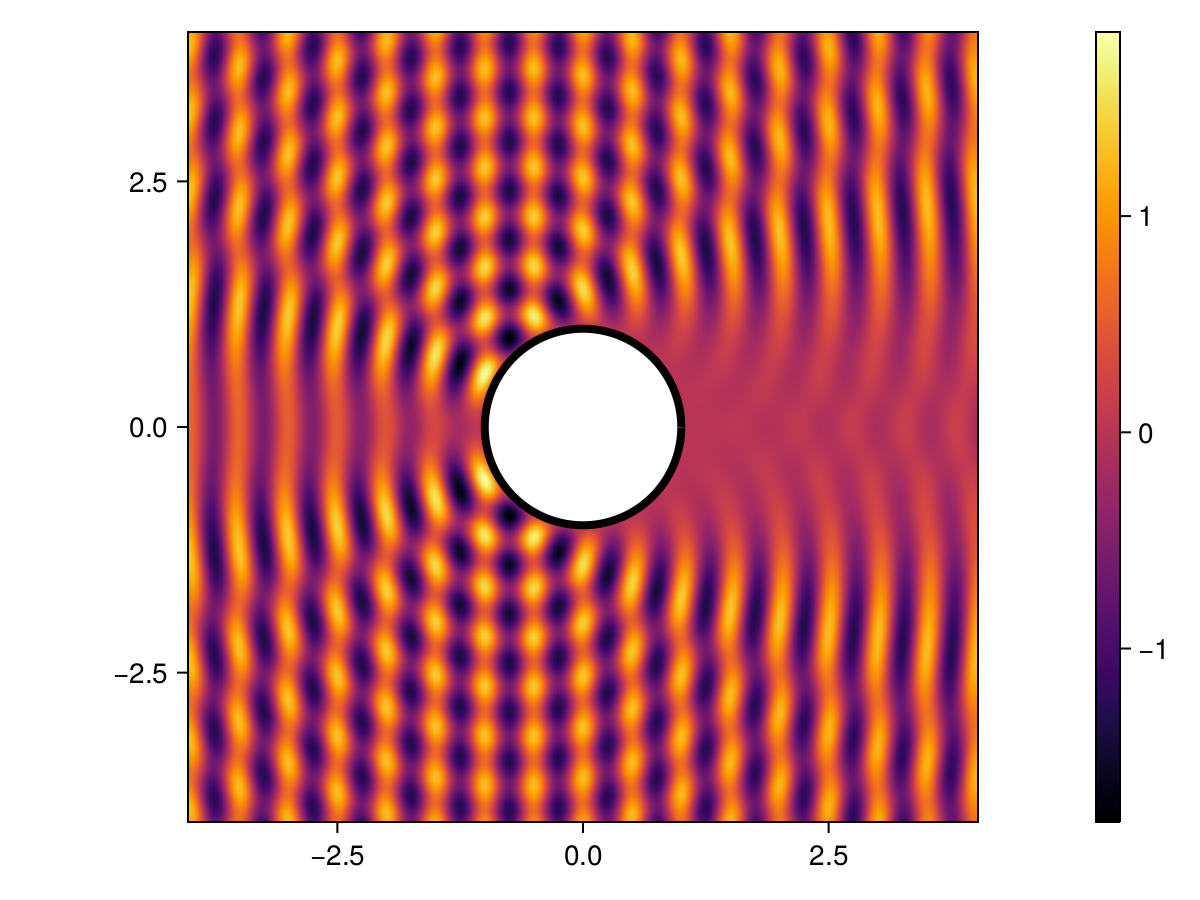

In [21]:
using CairoMakie
xx = yy = range(-4,stop=4,length=200)
vals = map(pt-> norm(pt) > 1 ? real(uₛ(pt) + uᵢ(pt)) : NaN, Iterators.product(xx,yy))
fig,ax,hm = heatmap(xx,yy,vals;
                    colormap=:inferno, interpolate=true,
                    axis=(aspect=DataAspect(),xgridvisible = false, ygridvisible = false),
                    )
lines!(ax,[cos(θ) for θ in 0:0.01:2π], [sin(θ) for θ in 0:0.01:2π], color=:black, linewidth=4)
Colorbar(fig[1,2], hm)
fig

More complex problems, however, may require a mesh-based visualization, where
we would first need to create a mesh for the places where we want to visualize
the solution. In the 3D example that follows, we will use the `Gmsh` API to
create a *view* (in the sense of *Gmsh*) of the solution on a punctured plane.

## Three-dimensional scattering

We now consider the same problem in 3D, being a bit more terse in the
explanation since many of the steps are similar. The main difficulty we will
try to address here is related to the computational complexity associated to
three-dimensional problems, where one needs to be careful not to assemble
and/or factor huge dense matrices! Instead of representing `Sop` and `Dop` as
dense matrices, and solving the system using `\` (which dispatches to to an
`LU` factorization in our case) we will:
- use hierarchical matrices to compress the integral operators
- rely on an iterative solver to solve the linear system

The following function will create a mesh of a sphere using the `Gmsh` API:

In [22]:
function gmsh_sphere(;name, meshsize, order=1, radius=1, center = (0,0,0))
    try
        gmsh.initialize()
        gmsh.model.add("sphere-mesh")
        gmsh.option.setNumber("Mesh.MeshSizeMax", meshsize)
        gmsh.option.setNumber("Mesh.MeshSizeMin", meshsize)
        gmsh.model.occ.addSphere(center[1], center[2], center[3], radius)
        gmsh.model.occ.synchronize()
        gmsh.model.mesh.generate(2)
        gmsh.model.mesh.setOrder(order)
        gmsh.write(name)
    finally
        gmsh.finalize()
    end
end

gmsh_sphere (generic function with 1 method)

As before, lets write a file with our mesh, and import it into `Inti.jl`, and
create a surface quadrature:

In [23]:
name = joinpath(@__DIR__, "sphere.msh")
gmsh_sphere(;meshsize=0.1, order = 2, name)
Ω,msh = Inti.gmsh_read_msh(name; dim=3)
Γ = Inti.boundary(Ω)
Q  = Inti.Quadrature(msh, Γ; qorder = 4)

Info    : Meshing 1D...
Info    : [ 40%] Meshing curve 2 (Circle)
Info    : Done meshing 1D (Wall 0.000143128s, CPU 0.000138s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Sphere, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.113222s, CPU 0.113213s)
Info    : 1578 nodes 3186 elements
Info    : Meshing order 2 (curvilinear on)...
Info    : [  0%] Meshing curve 1 order 2
Info    : [ 20%] Meshing curve 2 order 2
Info    : [ 40%] Meshing curve 3 order 2
Info    : [ 60%] Meshing surface 1 order 2
Info    : [ 80%] Meshing volume 1 order 2
Info    : Surface mesh: worst distortion = 0.997139 (0 elements in ]0, 0.2]); worst gamma = 0.593524
Info    : Done meshing order 2 (Wall 0.0141011s, CPU 0.014098s)
Info    : Writing '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/sphere.msh'...
Info    : Done writing '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/sphere.msh'
Info    : Reading '/home/lfaria/ru

18912-element Inti.Quadrature{3, Float64}:
 Inti.QuadratureNode{3, Float64}([-0.05373189629208194, -0.01161698092548756, 0.9984868469648277], 0.00118579869363884, [-0.05361621936255531, -0.011608545081622965, 0.9984941375403034])
 Inti.QuadratureNode{3, Float64}([-0.03492074140168075, 0.022170510743492314, 0.9991427196326353], 0.0011855731059084692, [-0.034983469901105964, 0.02212443248555452, 0.9991429659067167])
 Inti.QuadratureNode{3, Float64}([-0.031761986002829895, -0.036601557303946465, 0.998823824836464], 0.001185610720355747, [-0.03183434750584738, -0.03656404879293807, 0.998824130993412])
 Inti.QuadratureNode{3, Float64}([-0.011026214248489027, -0.002388771564555545, 0.9999355892140249], 0.0005832144771935263, [-0.01109284426595146, -0.0023958947761847133, 0.9999356021736162])
 Inti.QuadratureNode{3, Float64}([-0.05121457271448638, -0.07482546995496009, 0.9958790414559278], 0.0005850030694509388, [-0.051291538792827024, -0.074793521145121, 0.995879062558792])
 Inti.QuadratureN

!!! tip "Writing/reading a mesh from disk"
      Writing and reading a mesh to/from disk can be time consuming. You can
      avoid doing so by using `gmsh_import_mesh!`
      and `gmsh_import_domain` functions on an
      active `gmsh` model without writing it to disk.

We can now assemble the integral operators as before, being careful to use
`dim=3` when defining the Helmholtz PDE:

In [24]:
pde = Inti.Helmholtz(;k, dim=3)
G  = Inti.SingleLayerKernel(pde)
dGdny = Inti.DoubleLayerKernel(pde)

Sop = Inti.IntegralOperator(G,Q,Q)
Dop = Inti.IntegralOperator(dGdny,Q,Q)

18912×18912 Inti.IntegralOperator{ComplexF64}:
         -0.0-0.0im          …  -0.000587573-6.74426e-5im
  -0.00135192-4.54683e-5im      -0.000750374-3.49758e-5im
  -0.00153089-3.38217e-5im       -0.00045524-0.0001418im
  -0.00122332-5.75439e-5im      -0.000507137-0.000103778im
  -0.00094545-0.000117408im      -0.00036526-0.000226836im
 -0.000948445-0.000116288im  …   -0.00224481-3.12775e-6im
 -0.000545145-0.000234945im     -0.000362228-9.00805e-6im
 -0.000578174-0.000134575im     -0.000357295+6.03064e-5im
 -0.000590311-6.27741e-5im      -0.000347467+0.000102799im
 -0.000590576+6.03707e-5im      -0.000316163+0.000177058im
             ⋮               ⋱  
  -7.54547e-6+0.000593322im       1.24702e-5+0.000361965im
  -2.04192e-5+0.000593019im      -5.50286e-6+0.000362136im
  -7.49581e-6+0.000593321im  …    9.64956e-6+0.00036205im
  -0.00123291-5.8635e-5im       -0.000678233-4.57882e-5im
  -0.00321831-7.32377e-6im       -0.00057465-7.20534e-5im
  -0.00100932-9.87343e-5im      -0.000419692-

Here is how much memory it would take to store the dense representation of
these matrices:

In [25]:
mem = 2*length(Sop)*16/1e9 # 16 bytes per complex number, 1e9 bytes per GB, two matrices
println("memory required to store Sop and Dop: $(mem) GB")

memory required to store Sop and Dop: 11.445239808 GB


Even for this simple example, the dense representation of the integral
operators as matrix is already quite expensive. We will thus use hierarchical
matrix representation to compress things a bit:

In [26]:
import HMatrices
S_hmat = HMatrices.assemble_hmatrix(Sop;atol=1e-6)

HMatrix of ComplexF64 with range 1:18912 × 1:18912
	 number of nodes in tree: 18237
	 number of leaves: 13678 (4310 admissible + 9368 full)
	 min rank of sparse blocks : 7
	 max rank of sparse blocks : 42
	 min length of dense blocks : 1296
	 max length of dense blocks : 1369
	 min number of elements per leaf: 1296
	 max number of elements per leaf: 1397124
	 depth of tree: 9
	 compression ratio: 8.567452


In [27]:
D_hmat = HMatrices.assemble_hmatrix(Dop;atol=1e-6)

HMatrix of ComplexF64 with range 1:18912 × 1:18912
	 number of nodes in tree: 18237
	 number of leaves: 13678 (4310 admissible + 9368 full)
	 min rank of sparse blocks : 8
	 max rank of sparse blocks : 48
	 min length of dense blocks : 1296
	 max length of dense blocks : 1369
	 min number of elements per leaf: 1296
	 max number of elements per leaf: 1397124
	 depth of tree: 9
	 compression ratio: 7.545484


!!! note "Compression methods"
      It is worth mentioning that hierchical matrices are not the only way to
      compress such integral operators, and may in fact not even be the best
      for the problem at hand. For example, one could use a fast multipole
      method (FMM), which has a much lighter memory footprint, and is also
      faster to assemble. The main advantage of hierarchical matrices is that
      they are purely algebraic, allowing for the use of *direct solver*.
      Hierarchical matrices also tend to give a faster matrix-vector product
      after the (offline) assembly stage.

As in the 2D case, we need to correct `S_hmat` and `D_hmat` to account for the
singular and nearly-singular integrals. We will again use the density
interpolation method here:

In [28]:
δS, δD = Inti.bdim_correction(pde, Q, Q, S_hmat, D_hmat)
nothing #hide

We will use the generalized minimal residual (GMRES) iterative solver, for the
linear system. This requires us to define a linear operator `L`, approximating
the combined-field operator, that supports the matrix-vector product. In what
follows we use `LinearMaps` to *lazily* assemble `L`:

In [29]:
using LinearMaps
L = I/2 + (LinearMap(D_hmat) + LinearMap(δD)) - im*k*(LinearMap(S_hmat) + LinearMap(δS))

18912×18912 LinearMaps.LinearCombination{ComplexF64} with 4 maps:
  18912×18912 LinearMaps.ScaledMap{ComplexF64} with scale: -0.0 - 12.566370614359172im of
    18912×18912 LinearMaps.LinearCombination{ComplexF64} with 2 maps:
      18912×18912 LinearMaps.WrappedMap{ComplexF64} of
        18912×18912 HMatrix{ClusterTree{3, Float64}, ComplexF64}
      18912×18912 LinearMaps.WrappedMap{ComplexF64} of
        18912×18912 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 113472 stored entries
  18912×18912 LinearMaps.UniformScalingMap{Float64} with scaling factor: 0.5
  18912×18912 LinearMaps.WrappedMap{ComplexF64} of
    18912×18912 HMatrix{ClusterTree{3, Float64}, ComplexF64}
  18912×18912 LinearMaps.WrappedMap{ComplexF64} of
    18912×18912 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 113472 stored entries

We can now solve the linear system using GMRES solver (implemented in
`IterativeSolvers`):

In [30]:
using IterativeSolvers
rhs = map(Q) do q
    x = q.coords
    -uᵢ(x)
end
σ, hist = gmres(L, rhs; log=true, abstol=1e-6)
@show hist

hist = Converged after 18 iterations.


Converged after 18 iterations.

As before, let us represent the solution using `IntegralPotential`s:

In [31]:
𝒮 = Inti.IntegralPotential(G,Q)
𝒟 = Inti.IntegralPotential(dGdny,Q)
uₛ = x -> 𝒟[σ](x) - im*k*𝒮[σ](x)

#31 (generic function with 1 method)

To check the result, we compare against the exact solution obtained through a
series:

In [32]:
using GSL
sphbesselj(l,r) = sqrt(π/(2r)) * besselj(l+1/2,r)
sphbesselh(l,r) = sqrt(π/(2r)) * besselh(l+1/2,r)
sphharmonic(l,m,θ,ϕ) = GSL.sf_legendre_sphPlm(l,abs(m),cos(θ))*exp(im*m*ϕ)
function sphere_helmholtz_soundsoft(xobs;radius=1,k=1,θin=0,ϕin=0)
    x = xobs[1]
    y = xobs[2]
    z = xobs[3]
    r = sqrt(x^2+y^2+z^2)
    θ = acos(z/r)
    ϕ = atan(y,x)
    u = 0.0
    r < radius && return u
    c(l,m) = -4π*im^l*sphharmonic(l,-m,θin,ϕin)*sphbesselj(l,k*radius)/sphbesselh(l,k*radius)
    l = 0
    for l=0:60
        for m=-l:l
            u += c(l,m)*sphbesselh(l,k*r)*sphharmonic(l,m,θ,ϕ)
        end
        l += 1
    end
    return u
end

sphere_helmholtz_soundsoft (generic function with 1 method)

We will compute the error on some point on the sphere of radius `2`:

In [33]:
uₑ = (x) -> sphere_helmholtz_soundsoft(x;radius=1,k=k,θin=π/2,ϕin=0)
er = maximum(1:100) do _
    x̂ = rand(Inti.Point3D) |> normalize # an SVector of unit norm
    x = 2*x̂
    abs(uₛ(x) - uₑ(x))
end
@assert er < 1e-5 #hide
@info "error with correction = $er"

[ Info: error with correction = 8.46508763393124e-6


We see that the approximation is quite accurate. We can now export the
solution to *Gmsh* for visualization. To do so, we will first create a Gmsh
view ...

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*